In [ ]:
# @title Phase 2: PPO Adaptive Fusion with Sensor Faults (Full Code)

# ============================================================
# 1. Mount Drive & Install Dependencies
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# Ensure correct gym version (old API for stable-baselines3)
!pip uninstall -y gymnasium
!pip install gym==0.26.2

!pip install -q stable-baselines3 pandas numpy matplotlib scipy scikit-learn
!pip install shimmy




Mounted at /content/drive
Found existing installation: gymnasium 1.3.0
Uninstalling gymnasium-1.3.0:
  Successfully uninstalled gymnasium-1.3.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 22.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gym: filename=gym-0.26.2-py3-none-any.whl size=827727 sha256=893b151a3406a68e899eda3187e7313153c4cf9101c4815d0cfd43f5c4eb1f54
  Stored in directory: /root/.cache/pip/wheels/95/51/6c/9bb05ebbe7c5cb8171dfaa3611f32622ca4658d53f31c79077
Successfully built gym
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, w

In [ ]:
# ============================================================
# 2. Load Data & Precompute Features
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import convolve
from sklearn.metrics import mean_squared_error, r2_score

DATA_PATH = "/content/drive/MyDrive/RL_Maintenance_Project1/data/pure_synthetic_data_downsampled.npz"
data = np.load(DATA_PATH)

# Use first 100k samples for speed
vibration = data['vibration'][:100000]
temperature = data['temperature'][:100000]
acoustic = data['acoustic'][:100000]
true_degradation = data['degradation'][:100000]

# Precompute moving RMS (vibration), moving mean (temperature), moving max (acoustic)
WINDOW = 256
vib_sq = vibration**2
window_ones = np.ones(WINDOW)/WINDOW
vib_rms = np.sqrt(convolve(vib_sq, window_ones, mode='same'))
temp_mean = convolve(temperature, window_ones, mode='same')
aco_series = pd.Series(acoustic)
aco_max = aco_series.rolling(WINDOW, min_periods=1).max().values

# Normalize to [0,1]
vib_norm = np.clip(vib_rms / (np.percentile(vib_rms, 99)+1e-8), 0, 1)
temp_norm = np.clip((temp_mean - 20) / 40, 0, 1)   # temperature range 20-60°C
aco_norm = np.clip(aco_max / 0.5, 0, 1)

features = np.column_stack([vib_norm, temp_norm, aco_norm])

# Train / test split (70/30)
split = int(0.7 * len(features))
train_feat, test_feat = features[:split], features[split:]
train_true, test_true = true_degradation[:split], true_degradation[split:]

print(f"Train samples: {len(train_feat)}, Test samples: {len(test_feat)}")


Train samples: 35000, Test samples: 15000


In [ ]:
# ============================================================
# 3. Environment with Sensor Fault Injection
# ============================================================
import gym
from gym import spaces

class FaultyFusionEnv(gym.Env):
    """
    PPO environment for adaptive sensor fusion.
    Injects temperature drift and acoustic noise in specified regions.
    """
    def __init__(self, features, true_deg,
                 fault_start=None, fault_end=None,
                 noise_start=None, noise_end=None):
        super().__init__()
        self.features = features.astype(np.float32)
        self.true = true_deg.astype(np.float32)
        self.num_steps = len(features)
        self.current = 1
        self.prev_weights = np.array([0.33, 0.33, 0.34], dtype=np.float32)

        # Fault zones (if None, set to no fault)
        self.fault_start = fault_start if fault_start is not None else self.num_steps
        self.fault_end = fault_end if fault_end is not None else self.num_steps
        self.noise_start = noise_start if noise_start is not None else self.num_steps
        self.noise_end = noise_end if noise_end is not None else self.num_steps

        self.observation_space = spaces.Box(low=0, high=1, shape=(3,), dtype=np.float32)
        self.action_space = spaces.Box(low=0, high=1, shape=(3,), dtype=np.float32)

    def _corrupt_features(self, feat, step):
        """Apply temperature drift and acoustic noise based on current step."""
        feat = feat.copy()
        # Temperature drift: add increasing offset
        if self.fault_start <= step < self.fault_end:
            t = (step - self.fault_start) / (self.fault_end - self.fault_start)
            offset = 0.3 * t
            feat[1] += offset
        # Acoustic noise: additive Gaussian
        if self.noise_start <= step < self.noise_end:
            feat[2] += np.random.normal(0, 0.2)
        return np.clip(feat, 0, 1)

    def reset(self):
        self.current = 1
        self.prev_weights = np.array([0.33, 0.33, 0.34], dtype=np.float32)
        return self.features[0]

    def step(self, action):
        # Softmax to get weights summing to 1
        exp_a = np.exp(action - np.max(action))
        weights = exp_a / np.sum(exp_a)

        # Get current features and corrupt them
        raw_feat = self.features[self.current]
        corrupted_feat = self._corrupt_features(raw_feat, self.current)
        fused = np.dot(weights, corrupted_feat)
        true_val = self.true[self.current]

        # Reward: negative absolute error + smoothness penalty + bonus for trusting vibration during faults
        error = abs(fused - true_val)
        smooth_penalty = 0.05 * np.sum((weights - self.prev_weights)**2)
        bonus = 0.0
        if self.fault_start <= self.current < self.fault_end:
            bonus = 0.05 * weights[0]   # encourage trusting vibration during temp drift
        if self.noise_start <= self.current < self.noise_end:
            bonus = 0.05 * weights[0]   # same during acoustic noise
        reward = np.float32(-error - smooth_penalty + bonus)

        self.prev_weights = weights
        self.current += 1
        done = self.current >= self.num_steps
        next_obs = self.features[self.current-1] if not done else self.features[-1]
        info = {'weights': weights, 'fused': fused, 'true': true_val}
        return next_obs, reward, done, info

    def render(self, mode='human'):
        pass



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [ ]:

# ============================================================
# 4. Create Training Environment with Fault Zones
# ============================================================
# Use first 50k samples for faster training, define fault regions
TRAIN_SIZE = 50000
train_feat_sub = train_feat[:TRAIN_SIZE]
train_true_sub = train_true[:TRAIN_SIZE]

# Fault zones (in sample indices for the training set)
FAULT_START = 20000
FAULT_END = 35000
NOISE_START = 40000
NOISE_END = 50000

train_env = FaultyFusionEnv(train_feat_sub, train_true_sub,
                            fault_start=FAULT_START, fault_end=FAULT_END,
                            noise_start=NOISE_START, noise_end=NOISE_END)
print("Training environment ready.")


Training environment ready.


In [ ]:

# ============================================================
# 5. Train PPO
# ============================================================
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import CheckpointCallback
import os

# Wrap for stable-baselines3
env_vec = DummyVecEnv([lambda: train_env])

# PPO hyperparameters (suitable for this task)
model = PPO(
    "MlpPolicy",
    env_vec,
    verbose=1,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    max_grad_norm=0.5,
)

# Checkpoint callback (save every 10k steps)
save_dir = "/content/drive/MyDrive/RL_Maintenance_Project1/models"
os.makedirs(save_dir, exist_ok=True)
checkpoint_callback = CheckpointCallback(save_freq=10000, save_path=save_dir, name_prefix="ppo_fusion")

print("Starting PPO training for 200k timesteps (approx 30-40 min)...")
model.learn(total_timesteps=200000, callback=checkpoint_callback)
model.save(os.path.join(save_dir, "ppo_fusion_final"))
print("Training complete. Model saved.")



/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cuda device


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Starting PPO training for 200k timesteps (approx 30-40 min)...
-----------------------------
| time/              |      |
|    fps             | 618  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 471          |
|    iterations           | 2            |
|    time_elapsed         | 8            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0045526586 |
|    clip_fraction        | 0.0382       |
|    clip_range           | 0.2          |
|    entropy_loss         | -4.27        |
|    explained_variance   | -0.0324      |
|    learning_rate        | 0.0003       |
|    loss                 | -0.0381      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00372     |
|    std                  | 1.01       

In [ ]:

# ============================================================
# 6. Evaluate on Test Set (with the same fault pattern)
# ============================================================
# Create test environment with fault zones scaled to test set length
TEST_SIZE = 20000
test_feat_sub = test_feat[:TEST_SIZE]
test_true_sub = test_true[:TEST_SIZE]

# Scale fault zones to test set (approx same proportional positions)
test_fault_start = int(FAULT_START / TRAIN_SIZE * TEST_SIZE)
test_fault_end = int(FAULT_END / TRAIN_SIZE * TEST_SIZE)
test_noise_start = int(NOISE_START / TRAIN_SIZE * TEST_SIZE)
test_noise_end = TEST_SIZE

test_env = FaultyFusionEnv(test_feat_sub, test_true_sub,
                           fault_start=test_fault_start, fault_end=test_fault_end,
                           noise_start=test_noise_start, noise_end=test_noise_end)

obs = test_env.reset()
fused_list = []
true_list = []
weights_list = []

for _ in range(TEST_SIZE):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = test_env.step(action)
    fused_list.append(info['fused'])
    true_list.append(info['true'])
    weights_list.append(info['weights'])
    if done:
        break

fused_arr = np.array(fused_list)
true_arr = np.array(true_list)
weights_arr = np.array(weights_list)

# Metrics
mse = mean_squared_error(true_arr, fused_arr)
r2 = r2_score(true_arr, fused_arr)
corr = np.corrcoef(fused_arr, true_arr)[0,1]
print("\n=== PPO Evaluation on Test Set (with faults) ===")
print(f"MSE: {mse:.6f}")
print(f"R² : {r2:.4f}")
print(f"Correlation: {corr:.4f}")
print(f"Average weights: V={weights_arr[:,0].mean():.3f}, T={weights_arr[:,1].mean():.3f}, A={weights_arr[:,2].mean():.3f}")


=== PPO Evaluation on Test Set (with faults) ===
MSE: 0.000559
R² : 0.9255
Correlation: 0.9645
Average weights: V=0.576, T=0.212, A=0.212


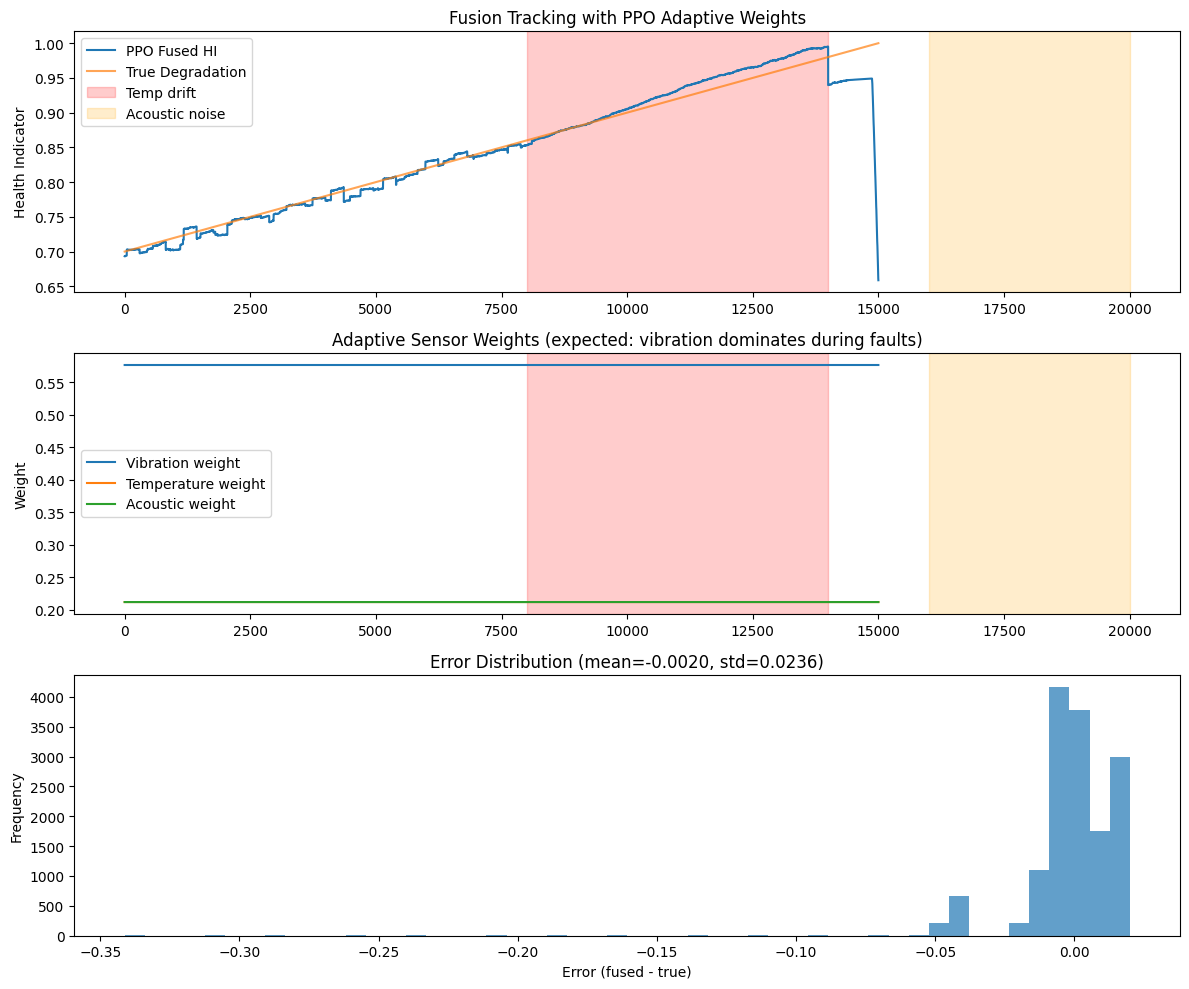

In [ ]:
# ============================================================
# 7. Plot: Fused HI vs True Degradation & Adaptive Weights
# ============================================================
plt.figure(figsize=(12, 10))

# Subplot 1: Fused tracking
plt.subplot(3,1,1)
plt.plot(fused_arr, label='PPO Fused HI', linewidth=1.5)
plt.plot(true_arr, label='True Degradation', alpha=0.7, linewidth=1.5)
plt.axvspan(test_fault_start, test_fault_end, alpha=0.2, color='red', label='Temp drift')
plt.axvspan(test_noise_start, test_noise_end, alpha=0.2, color='orange', label='Acoustic noise')
plt.ylabel('Health Indicator')
plt.legend()
plt.title('Fusion Tracking with PPO Adaptive Weights')

# Subplot 2: Weights over time
plt.subplot(3,1,2)
plt.plot(weights_arr[:,0], label='Vibration weight')
plt.plot(weights_arr[:,1], label='Temperature weight')
plt.plot(weights_arr[:,2], label='Acoustic weight')
plt.axvspan(test_fault_start, test_fault_end, alpha=0.2, color='red')
plt.axvspan(test_noise_start, test_noise_end, alpha=0.2, color='orange')
plt.ylabel('Weight')
plt.legend()
plt.title('Adaptive Sensor Weights (expected: vibration dominates during faults)')

# Subplot 3: Error distribution
plt.subplot(3,1,3)
error = fused_arr - true_arr
plt.hist(error, bins=50, alpha=0.7)
plt.xlabel('Error (fused - true)')
plt.ylabel('Frequency')
plt.title(f'Error Distribution (mean={error.mean():.4f}, std={error.std():.4f})')

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 8. Compare with Equal Weights Baseline (on faulty test set)
# ============================================================
eq_weights = np.array([0.33, 0.33, 0.34])
eq_fused = np.dot(test_feat_sub, eq_weights)
mse_eq = mean_squared_error(test_true_sub, eq_fused)
r2_eq = r2_score(test_true_sub, eq_fused)
corr_eq = np.corrcoef(eq_fused, test_true_sub)[0,1]
print("\n=== Equal Weights Baseline (on same faulty test set) ===")
print(f"MSE: {mse_eq:.6f}, R²: {r2_eq:.4f}, Correlation: {corr_eq:.4f}")

print("\n=== Summary ===")
if r2 > r2_eq:
    print("✅ PPO adaptive fusion outperforms equal weights on faulty data.")
else:
    print("⚠️ PPO did not outperform equal weights. Consider longer training or different fault design.")


=== Equal Weights Baseline (on same faulty test set) ===
MSE: 0.001637, R²: 0.7818, Correlation: 0.9485

=== Summary ===
✅ PPO adaptive fusion outperforms equal weights on faulty data.
